<a href="https://colab.research.google.com/github/krushna1133/NNDL-Practical/blob/main/NNDL_Practical7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload file for object detection!! 


Saving pexels-562238395-18366975.jpg to pexels-562238395-18366975 (2).jpg
car: 75.24%
car: 71.30%
car: 70.92%
car: 69.48%
car: 66.89%
car: 64.85%
car: 64.05%
car: 63.88%
car: 61.92%
car: 61.90%
car: 60.99%
car: 59.48%
car: 59.15%
car: 58.96%
car: 58.60%
car: 57.92%
truck: 57.85%
car: 57.54%
car: 57.46%
car: 56.84%
car: 56.14%
car: 55.95%
truck: 55.40%
car: 54.78%
car: 54.17%
car: 54.06%
car: 54.02%
car: 53.64%
truck: 53.46%
car: 52.53%
car: 52.29%
car: 52.01%
car: 51.88%
bus: 51.77%
car: 51.07%
truck: 50.91%
car: 50.82%
car: 50.03%

Total objects: 38
Average confidence: 58.16%


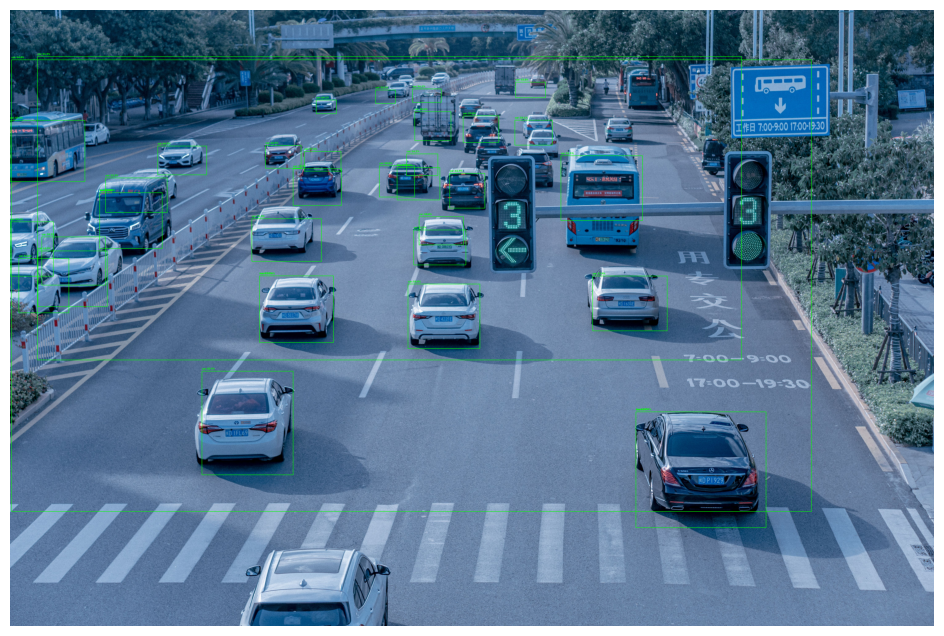

In [4]:
!pip -q install tensorflow-hub

import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from PIL import Image
import cv2

# 1. Upload image
print("Upload file for object detection!! ")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# 2. Read image
image = Image.open(image_path).convert("RGB")
image_np = np.array(image)
height, width, _ = image_np.shape

# 3. Load SSD MobileNet
model = hub.load("https://tfhub.dev/tensorflow/ssd_mobilenet_v2/2")

# 4. Detect objects
input_image = tf.expand_dims(image_np, 0)
detections = model(input_image)

boxes = detections["detection_boxes"][0].numpy()
classes = detections["detection_classes"][0].numpy().astype(int)
scores = detections["detection_scores"][0].numpy()

# 5. Object names
COCO = {
    1:"person", 2:"bicycle", 3:"car", 4:"motorcycle",
    6:"bus", 8:"truck", 16:"bird", 17:"cat", 18:"dog",
    19:"horse", 20:"sheep", 21:"cow", 22:"elephant",
    23:"bear", 24:"zebra", 25:"giraffe", 27:"backpack",
    28:"umbrella", 31:"handbag", 44:"bottle", 47:"cup",
    62:"chair", 63:"couch", 64:"potted plant", 65:"bed",
    67:"dining table", 72:"tv", 73:"laptop", 77:"cell phone",
    84:"book", 85:"clock", 86:"vase"
}

# 6. Draw detected objects
detected = []

for box, class_id, score in zip(boxes, classes, scores):

    if score >= 0.5 and class_id in COCO:

        y1, x1, y2, x2 = box

        x1, x2 = int(x1 * width), int(x2 * width)
        y1, y2 = int(y1 * height), int(y2 * height)

        name = COCO[class_id]
        detected.append(score)

        cv2.rectangle(
            image_np,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2
        )

        cv2.putText(
            image_np,
            f"{name}: {score*100:.1f}%",
            (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2
        )

        print(f"{name}: {score*100:.2f}%")

# 7. Results
print("\nTotal objects:", len(detected))

if detected:
    print("Average confidence:", f"{np.mean(detected)*100:.2f}%")
else:
    print("No objects detected.")

# 8. Show result
plt.figure(figsize=(12, 8))
plt.imshow(image_np)
plt.axis("off")
plt.show()
